## The SARIMA Model (Adding seasonality (S) to the ARIMA model)

The power of the SARIMA model is that it needs to use only the history of the target 
variable, which can be applied to very many cases of forecasting. Within univariate 
time series modeling, the SARIMA model is the most complete model, using AR, MA, 
integration for modeling trends, and seasonality.

The `MODEL formular` is on page 116.

In this model, you can observe the following parts:
* The regular AR part, with the coefficients φp (small phis)
* The seasonal AR part, with the coefficients φ
 (capital phis)
* The regular MA part, with the coefficients θq (small thetas)
* The seasonal MA part, with the coefficients θ
 (capital thetas)
* The regular integration part, indicated by order d
* The seasonal integration part, indicated by order D
* Coefficient of seasonality s


The same hyperparameters as before still need to be decided on:
* p for the AR order
* q for the MA order
* I for the differencing order

To this are added three more orders:


* P for the seasonal AR order
* Q for the seasonal MA order
* D for the seasonal differencing

the parameter `s` is the seasonal period. This `s` is not 
a hyperparameter like the other orders. `s` should not be tested using a grid search; rather, it 
should be decided based on logic. The `s` is the periodicity of the seasonality. If you work with 
monthly data, you should choose 12; if you work with weekly data, you should choose 52.

### SARIMA on Walmart Sales

We will apply SARIMA on walmart sales store forcasting dataset.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('../database/walmart-recruiting-store-sales-forecasting-Copy/train.csv/train.csv')
data

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


In [4]:
data = data.groupby('Date').sum()
data

,Store,Dept,Weekly_Sales,IsHoliday
Date,,,,
2010-02-05,65124,130557,49750740.50,0
2010-02-12,65082,131179,48336677.63,2956
2010-02-19,65610,131897,48276993.78,0
2010-02-26,65045,130161,43968571.13,0
2010-03-05,64897,129670,46871470.30,0
...,...,...,...,...
2012-09-28,65866,130785,43734899.40,0
2012-10-05,66296,132468,47566639.31,0
2012-10-12,66453,133371,46128514.25,0


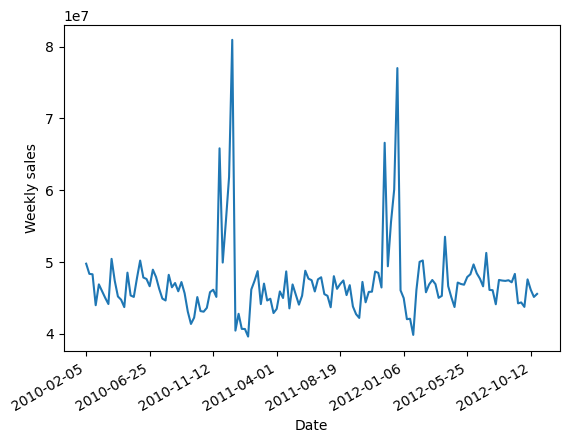

In [5]:
ax = data['Weekly_Sales'].plot()
ax.set_ylabel('Weekly sales')
plt.gcf().autofmt_xdate()
plt.show()